<a href="https://colab.research.google.com/github/aditya-ailsinghani/fifa22-player-value-analytics/blob/main/eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
PROJECT_PATH = "/content/drive/MyDrive/Projects/Fifa_Analytics"
os.chdir(PROJECT_PATH)

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
sns.set_style("whitegrid")

In [4]:
df = pd.read_csv("FIFA22_cleaned.csv")
df.shape

(16710, 64)

Age Distribution

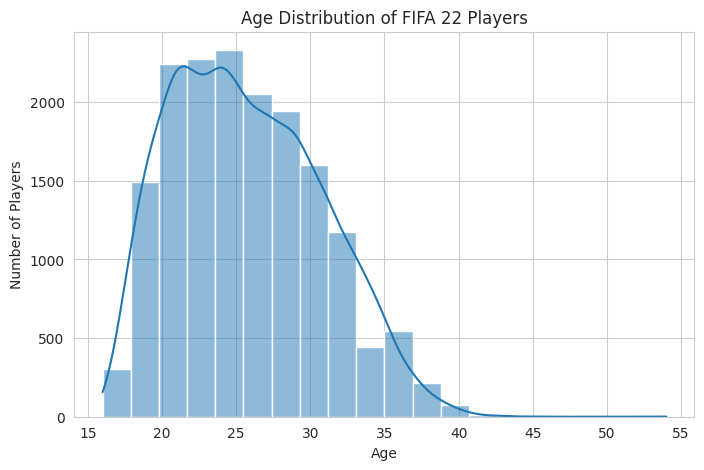

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution of FIFA 22 Players")
plt.xlabel("Age")
plt.ylabel("Number of Players")
plt.show()

Most professional players are concentrated between ages 18-35, after 30 the number of players steadily decline and very few remain post 40

Ovr Rating Distribution

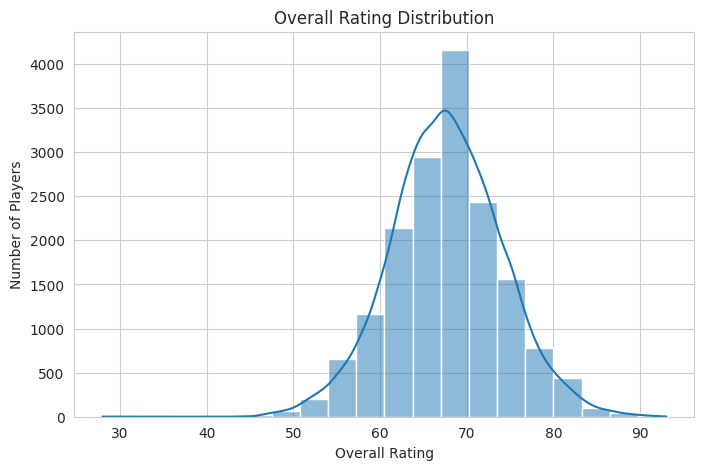

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df["Overall"], bins=20, kde=True)
plt.title("Overall Rating Distribution")
plt.xlabel("Overall Rating")
plt.ylabel("Number of Players")
plt.show()

Player ratings are heavily concentrated around 68–72, with far fewer players at elite ratings (85+).
Extremely high-rated players (90+) are rare, forming a small elite group.

Value v/s Age

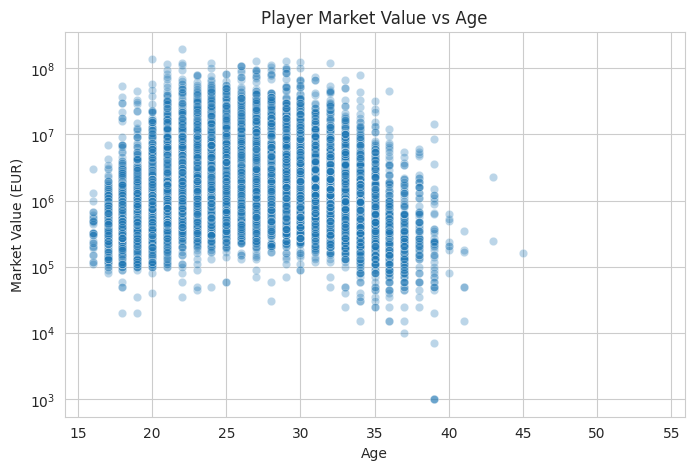

In [7]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Age",
    y="Value_EUR",
    data=df,
    alpha=0.3
)
plt.title("Player Market Value vs Age")
plt.xlabel("Age")
plt.ylabel("Market Value (EUR)")
plt.yscale("log")  # value is very skewed
plt.show()

Players are most valuable when they combine strong performance with future potential.
Once players pass their athletic peak, market value declines quickly, regardless of experience.

value v/s overall rating

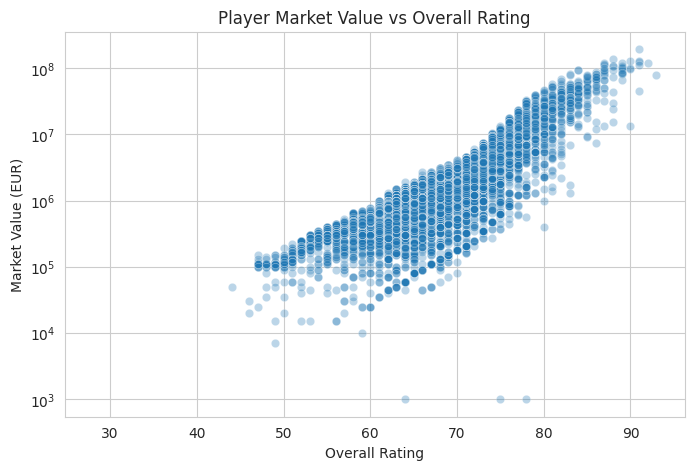

In [8]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x="Overall",
    y="Value_EUR",
    data=df,
    alpha=0.3
)
plt.title("Player Market Value vs Overall Rating")
plt.xlabel("Overall Rating")
plt.ylabel("Market Value (EUR)")
plt.yscale("log")
plt.show()

Player value doesn’t increase linearly with skill.
Once a player crosses an elite performance threshold, their market value skyrockets.

Creating value tiers

In [9]:
# Define value tiers using percentiles
high_value_threshold = df["Value_EUR"].quantile(0.90)

df["Value_Tier"] = np.where(
    df["Value_EUR"] >= high_value_threshold,
    "Top 10% Value",
    "Bottom 90%"
)

df["Value_Tier"].value_counts()

,count
Value_Tier,
Bottom 90%,14944
Top 10% Value,1766


High-value players are rare, which explains why the market prices them aggressively.

Compare key attributes by value tier

Start with Overall and Age

In [10]:
df.groupby("Value_Tier")[["Overall", "Age"]].mean()

,Overall,Age
Value_Tier,,
Bottom 90%,66.390926,25.663075
Top 10% Value,78.269536,26.271801


High-value players are not just slightly better they are significantly more skilled than the average professional.

Age by itself does not separate high-value players from others.
Skill level matters far more, as long as players are within a “prime” age range.

Attributes that differentiate hight value players

In [11]:
key_attributes = [
    "Finishing",
    "Dribbling",
    "ShortPassing",
    "BallControl",
    "Acceleration",
    "SprintSpeed",
    "Stamina",
    "Strength",
    "Vision",
    "Composure"
]

df.groupby("Value_Tier")[key_attributes].mean()

,Finishing,Dribbling,ShortPassing,BallControl,Acceleration,SprintSpeed,Stamina,Strength,Vision,Composure
Value_Tier,,,,,,,,,,
Bottom 90%,47.415953,57.164815,59.929069,59.979457,64.950348,65.030782,63.137982,65.773488,54.939775,59.522283
Top 10% Value,59.802945,70.661382,73.037373,73.301812,71.900906,72.149490,73.229898,70.433749,68.591166,73.664213


To better understand what differentiates high-value players from the rest, we compared the average attributes of the top 10% most valuable players against those of the remaining bottom 90%. The results show clear and meaningful differences across nearly all attributes, but the magnitude of these differences varies by skill type.

The most striking gaps appear in technical and mental attributes. High-value players significantly outperform others in skills such as ball control, dribbling, short passing, finishing, vision, and composure, often by more than 10 rating points on average. These attributes are closely tied to a player’s ability to influence the game in complex situations — maintaining control under pressure, making better decisions, and consistently executing high-impact actions. This suggests that elite market value is strongly associated with game intelligence and technical reliability, rather than just raw athleticism.

Physical attributes such as acceleration, sprint speed, stamina, and strength are also higher among top-value players, but the differences are noticeably smaller in comparison. While physical ability is clearly important for competing at the professional level, it does not appear to be the primary factor that separates elite players from the broader population. In other words, many players may be fast or strong, but far fewer possess the technical precision and composure required at the highest levels.

Overall, this analysis indicates that player market value is driven less by basic physical traits and more by advanced technical skills and mental attributes that directly impact performance quality and consistency. This aligns with real-world football valuation, where players who can control play, create chances, and perform under pressure command a significant premium in the transfer market.

How do value drivers differ by position

In [12]:
df["Best Position"].value_counts().head(10)

,count
Best Position,
CB,3214
ST,2549
CAM,2203
GK,1546
RM,1313
CDM,1262
CM,1011
RB,856
LB,813


Now we will find value drivers for top 3 postions, ST, CAM and CB

In [13]:
st_df = df[df["Best Position"] == "ST"]

st_df.groupby("Value_Tier")[[
    "Finishing",
    "Positioning",
    "ShotPower",
    "BallControl",
    "Acceleration",
    "SprintSpeed",
    "Composure"
]].mean()

,Finishing,Positioning,ShotPower,BallControl,Acceleration,SprintSpeed,Composure
Value_Tier,,,,,,,
Bottom 90%,67.245324,66.53284,68.207047,65.134406,68.30274,69.671596,61.526751
Top 10% Value,80.144000,80.40800,79.656000,77.336000,75.19600,76.972000,75.012000


When comparing high- and low-value strikers, the largest differences appear in attributes directly related to goal scoring and decision-making. High-value strikers significantly outperform others in finishing, positioning, ball control, and composure, indicating that elite attackers are distinguished by their ability to consistently convert chances and remain effective under pressure. While physical attributes such as speed and shot power are also higher among top-value strikers, the gaps are smaller in comparison. This suggests that market value for strikers is driven primarily by clinical efficiency and intelligent movement, rather than raw athleticism alone.

In [14]:
cb_df = df[df["Best Position"] == "CB"]

cb_df.groupby("Value_Tier")[[
    "DefensiveAwareness",
    "StandingTackle",
    "SlidingTackle",
    "Interceptions",
    "Strength",
    "Jumping",
    "Composure"
]].mean()

,DefensiveAwareness,StandingTackle,SlidingTackle,Interceptions,Strength,Jumping,Composure
Value_Tier,,,,,,,
Bottom 90%,64.733675,67.812991,65.585983,65.490940,76.600000,71.761368,59.458120
Top 10% Value,78.598616,80.138408,78.072664,78.813149,81.712803,77.640138,73.034602


Comparing high- and low-value center backs shows that market value is driven primarily by defensive intelligence and reliability. High-value center backs significantly outperform others in defensive awareness, tackling, interceptions, and composure, highlighting the importance of positioning, anticipation, and decision-making. While physical attributes such as strength and jumping ability are also higher among elite defenders, the differences are smaller, suggesting that physicality alone is insufficient to command high market value. Instead, consistent defensive decision-making and composure under pressure play a central role in differentiating top-value center backs.

In [15]:
cam_df = df[df["Best Position"] == "CAM"]

cam_df.groupby("Value_Tier")[[
    "Vision",
    "ShortPassing",
    "BallControl",
    "Dribbling",
    "Composure",
    "LongShots",
    "Acceleration"
]].mean()

,Vision,ShortPassing,BallControl,Dribbling,Composure,LongShots,Acceleration
Value_Tier,,,,,,,
Bottom 90%,65.614331,67.567966,68.630137,68.401475,62.983140,60.779241,70.438356
Top 10% Value,77.780328,78.134426,80.845902,81.219672,76.177049,73.940984,78.163934


Among attacking midfielders, high market value is most strongly associated with creative and technical attributes. High-value CAMs significantly outperform others in vision, short passing, ball control, dribbling, long shots, and composure, highlighting the importance of playmaking ability and technical control. While acceleration is also higher among top-value players, the difference is smaller, indicating that creativity and decision-making play a far greater role in determining value for this position. Overall, elite attacking midfielders are valued for their ability to influence the game through intelligent distribution and composure rather than physical speed alone.

**Summary for Value Drivers by Position**

This analysis shows that player market value is driven by different attributes depending on positional role, while a common theme of decision-making and technical reliability remains consistent. For strikers, value is driven by finishing ability, positioning, and composure, reflecting the premium placed on consistent goal-scoring. For center backs, defensive awareness, tackling, interceptions, and composure are the primary differentiators, emphasizing intelligence and reliability over physicality alone. For attacking midfielders, creativity-related attributes such as vision, passing, ball control, and composure play the dominant role. Across all positions, technical quality and mental attributes consistently outweigh raw physical traits, suggesting that elite market value is primarily driven by how effectively a player applies their skills within their positional role.

**OVERALL EDA CONCLUSIONS**

This exploratory analysis examined FIFA 22 player data to understand the key factors that drive player market value. At a high level, player value is strongly associated with overall performance quality, with elite-rated players representing a small and highly valued segment of the market. While age plays a role by defining a player’s prime window, it is not a primary differentiator among high-value players once they are within a typical professional age range.

A comparison between high-value and low-value players revealed that technical and mental attributes—such as ball control, passing, vision, finishing, and composure—are consistently more important than purely physical traits. Although speed and strength contribute to performance, they do not sufficiently explain why certain players command significantly higher market value.

Further position-based analysis demonstrated that value drivers vary by role, but a common pattern remains. Strikers are valued for finishing ability, positioning, and composure; center backs for defensive awareness, anticipation, and reliability; and attacking midfielders for creativity, ball control, and decision-making. Across all positions, players who apply their skills intelligently and consistently under pressure are rewarded with higher market value.

**Implications for modeling**

The findings from this exploratory analysis suggest that player market value can be reasonably modeled using a combination of technical, mental, and role-specific attributes, with overall rating and key position-relevant skills expected to be strong predictors. These insights guide the feature selection and modeling strategy used in the next stage of the project, where predictive models are developed to estimate player market value based on performance characteristics

**What this notebook accomplished**

This EDA notebook established a clear understanding of the FIFA 22 player landscape, identified the primary drivers of player market value, and demonstrated that valuation logic differs meaningfully by position. These insights provide both business-relevant interpretations and a data-driven foundation for predictive modeling.